### In this script, different pipelines were tested using the Conch zero shot classifier and its accuracy was benchmarked on the CRC100K dataset.
### Different pipelines such as using top 3 labels per patch to then include one patch in 3 different clusters and then get a slide level classification

In [ ]:
import os
from pathlib import Path
import json

from conch.open_clip_custom import create_model_from_pretrained
from conch.downstream.zeroshot_path import zero_shot_classifier, run_zeroshot

import torch      
import torch.nn.functional as F
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# display all jupyter output
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

d:\miniconda_3\envs\conch-env\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
d:\miniconda_3\envs\conch-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\miniconda_3\envs\conch-env\Lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
root = Path('../').resolve()
os.chdir(root)

This notebook provides a complete example for performing zero-shot classification by ensembling multiple prompts and prompt templates. You can use this notebook to reproduce the zero-shot classification results on CRC100K (image size = 224 x 224). 

In [3]:
model_cfg = 'conch_ViT-B-16'
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
checkpoint_path = "D:\DataInsight\Label_matching\checkpoints\CONCH\pytorch_model.bin"
force_image_size = 224
model, preprocess = create_model_from_pretrained(model_cfg, checkpoint_path, device=device,
                                                 force_image_size=force_image_size)
_ = model.eval()

In [4]:
# data_source = '/path/to/CRC100k/validation/set'
data_source = "D:\DataInsight\Label_matching\TCGA-3L-AA1B_nonMSIH_subset"
dataset = ImageFolder(data_source, transform=preprocess)
dataloader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=4)
if hasattr(dataloader.dataset, 'class_to_idx'):
     idx_to_class = {v:k for k,v in dataloader.dataset.class_to_idx.items()}
else:
     raise ValueError('Dataset does not have label_map attribute')
print("num samples: ", len(dataloader.dataset))
print(idx_to_class)

FileNotFoundError: Couldn't find any class folder in D:\DataInsight\Label_matching\TCGA-3L-AA1B_nonMSIH_subset.

In [ ]:
# prompt_file = './prompts/crc100k_prompts_all_per_class.json'
prompt_file = "D:\DataInsight\Label_matching\datasets\config_tcga-ot-V2.yaml"
with open(prompt_file) as f:
    prompts = json.load(f)['0']
classnames = prompts['classnames']
templates = prompts['templates']
n_classes = len(classnames)
classnames_text = [classnames[str(idx_to_class[idx])] for idx in range(n_classes)]
for class_idx, classname in enumerate(classnames_text):
    print(f'{class_idx}: {classname}')

In [ ]:
zeroshot_weights = zero_shot_classifier(model, classnames_text, templates, device=device)
print(zeroshot_weights.shape)

In [ ]:
results, dump = run_zeroshot(model, zeroshot_weights, dataloader, device, 
                    dump_results=True, metrics=['bacc', 'weighted_f1'])

In [ ]:
for k, v in results.items():
    print(f'{k}: {v:.3f}')

## Testing

In [14]:
import torch
import pandas as pd
from tqdm import tqdm
import yaml
import torch

# Load dict from file
feature_path = r"D:\DataInsight\Label_matching\TCGA-3L-AA1B_nonMSIH_patch_features.pt"
features_dict = torch.load(feature_path, weights_only=False)

# Extract patch features
features_tensor = features_dict['features']  # Shape: [1, N, 768] or [N, 768]

# Squeeze batch dimension if needed
if features_tensor.ndim == 3:
    features_tensor = features_tensor.squeeze(0)

# Take only the first 50
features_tensor = features_tensor[:50]  # Shape: [50, 768]

# Move to device
device = "cuda" if torch.cuda.is_available() else "cpu"
features_tensor = features_tensor.to(device)

In [ ]:
import yaml

prompt_file = r"D:\DataInsight\Label_matching\datasets\config_tcga-ot-V2.yaml"

# Load YAML
with open(prompt_file, 'r') as f:
    config = yaml.safe_load(f)

# Get label dictionary (maps class names to indices)
label_dict = config['label_dict']

# Sort label names by their index to get consistent ordering
sorted_classnames = dict(sorted(label_dict.items(), key=lambda item: item[1]))
classnames = list(sorted_classnames.keys())  # e.g., ['Adipose-Fat', 'Debris-Necrosis', ...]

# Extract prompts (templates per class)
prompts_dict = config['prompts']

# For each class, build prompt list using one or more templates
# You can apply multiple prompts per class, or just pick one
# templates = ["This patch contains {}."]  # Your own general template

TEMPLATES = [
    "CLASSNAME.",
    "a photomicrograph showing CLASSNAME.",
    "a photomicrograph of CLASSNAME.",
    "an image of CLASSNAME.",
    "an image showing CLASSNAME.",
    "an example of CLASSNAME.",
    "CLASSNAME is shown.",
    "this is CLASSNAME.",
    "there is CLASSNAME.",
    "a histopathological image showing CLASSNAME.",
    "a histopathological image of CLASSNAME.",
    "a histopathological photograph of CLASSNAME.",
    "a histopathological photograph showing CLASSNAME.",
    "shows CLASSNAME.",
    "presence of CLASSNAME.",
    "CLASSNAME is present.",
    "an H&E stained image of CLASSNAME.",
    "an H&E stained image showing CLASSNAME.",
    "an H&E image showing CLASSNAME.",
    "an H&E image of CLASSNAME.",
    "CLASSNAME, H&E stain.",
    "CLASSNAME, H&E."
]

# Create final prompt list per class using the first prompt (or all if you want to average later)
classnames_text = [prompts_dict[c][0] if isinstance(prompts_dict[c], list) else c for c in classnames]

# Print to confirm
for i, name in enumerate(classnames_text):
    print(f"{i}: {name}")


0: adipose
1: debris
2: inflammatory
3: plasma cells
4: lymphoid aggregate
5: mucus
6: smooth muscle
7: normal mucosa
8: adenoma
9: tumor associated stroma
10: stroma
11: adenocarcinoma
12: poorly differentiated
13: signet ring


In [16]:
zeroshot_weights = zero_shot_classifier(model, classnames, templates, device=device)

zeroshot_weights = zeroshot_weights.to(device)

In [17]:
# Run inference
results = []
with torch.inference_mode():
    for i, patch_feat in enumerate(tqdm(features_tensor, desc="Classifying patch features")):
        patch_feat = patch_feat.unsqueeze(0)  # Shape: [1, 768]
        logits = patch_feat @ zeroshot_weights.T  # [1, C]
        probs = torch.softmax(logits, dim=-1)
        pred_idx = torch.argmax(probs, dim=-1).item()
        pred_label = classnames_text[pred_idx]
        results.append((f"patch_{i:04d}", pred_label, probs.squeeze().tolist()))

# Print results
for fname, label, _ in results:
    print(f"{fname} → {label}")

# Save to CSV (optional)
df = pd.DataFrame(results, columns=["patch_id", "predicted_class", "probs"])
df.to_csv("patch_zeroshot_predictions_Conch.csv", index=False)

Classifying patch features:   0%|          | 0/50 [00:00<?, ?it/s]


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x768 and 14x512)

## Method 2 (Load direct PNGs)

In [4]:
import os
import yaml
import torch
import pandas as pd
from pathlib import Path
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from conch.open_clip_custom import create_model_from_pretrained
from conch.downstream.zeroshot_path import zero_shot_classifier

# ==============================
# Config paths
# ==============================
yaml_file = r"D:\DataInsight\Label_matching\datasets\config_tcga-ot-V2.yaml"
data_source = Path(r"D:\DataInsight\Label_matching\Sample_Data\Test_data")  # contains subfolders per slide
checkpoint_path = "./checkpoints/CONCH/pytorch_model.bin"
model_cfg = 'conch_ViT-B-16'
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
force_image_size = 224

# ==============================
# Load yaml prompts
# ==============================
with open(yaml_file, 'r') as f:
    cfg = yaml.safe_load(f)

label_dict = cfg['label_dict']  # mapping {caption: id}
id_to_label = {v: k for k, v in label_dict.items()}

# Flatten prompts into classnames list
classnames_text = list(label_dict.keys())
templates = [
    "CLASSNAME.",
    "a photomicrograph showing CLASSNAME.",
    "a photomicrograph of CLASSNAME.",
    "an image of CLASSNAME.",
    "an image showing CLASSNAME.",
    "an example of CLASSNAME.",
    "CLASSNAME is shown.",
    "this is CLASSNAME.",
    "there is CLASSNAME.",
    "a histopathological image showing CLASSNAME.",
    "a histopathological image of CLASSNAME.",
    "a histopathological photograph of CLASSNAME.",
    "a histopathological photograph showing CLASSNAME.",
    "shows CLASSNAME.",
    "presence of CLASSNAME.",
    "CLASSNAME is present.",
    "an H&E stained image of CLASSNAME.",
    "an H&E stained image showing CLASSNAME.",
    "an H&E image showing CLASSNAME.",
    "an H&E image of CLASSNAME.",
    "CLASSNAME, H&E stain.",
    "CLASSNAME, H&E."
]

# ==============================
# Load model
# ==============================
model, preprocess = create_model_from_pretrained(
    model_cfg, checkpoint_path, device=device, force_image_size=force_image_size
)
_ = model.eval()

print(data_source)

D:\DataInsight\Label_matching\Sample_Data\Test_data


In [7]:
print(preprocess)

Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    <function _convert_to_rgb at 0x000002365CF9CE00>
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)


In [5]:
# ==============================
# Prepare dataset
# ==============================
dataset = ImageFolder(str(data_source), transform=preprocess)
dataloader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=4)

In [6]:
# ==============================
# Create zeroshot weights
# ==============================
zeroshot_weights = zero_shot_classifier(model, classnames_text, templates, device=device)

# ==============================
# Predict
# ==============================
all_rows = []
with torch.no_grad():
    for images, _ in dataloader:
        images = images.to(device)
        image_features = model.encode_image(images)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        # similarity to captions
        logits = image_features @ zeroshot_weights
        preds = torch.argmax(logits, dim=-1).cpu().numpy()

        # map to filenames
        batch_paths = [dataset.samples[i][0] for i in range(len(all_rows), len(all_rows) + len(images))]
        for pth, pred_id in zip(batch_paths, preds):
            patch_name = os.path.basename(pth)
            slide_name = os.path.basename(os.path.dirname(pth))
            caption_str = id_to_label[pred_id]
            all_rows.append({
                "patch_name": patch_name,
                "slide_name": slide_name,
                "predicted_caption": caption_str,
                "predicted_label_id": pred_id
            })

# ==============================
# Save DataFrame
# ==============================
df = pd.DataFrame(all_rows)
df.to_csv("patch_predictions.csv", index=False)
print("Saved to patch_predictions.csv")


Saved to patch_predictions.csv


## Pipeline 1 fivecrop

In [11]:
import os
import yaml
import torch
import pandas as pd
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torchvision import transforms
import traceback

from conch.open_clip_custom import create_model_from_pretrained
from conch.downstream.zeroshot_path import zero_shot_classifier

print("Starting patch classification pipeline...")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# ==============================
# Config
# ==============================
yaml_file = r"D:\DataInsight\Label_matching\datasets\config_CRC100k.yaml"
data_source = Path(r"D:\DataInsight\Label_matching\Sample_Data\Test_data")  # contains subfolders per slide
checkpoint_path = "./checkpoints/CONCH/pytorch_model.bin"
non_white_csv = r"D:\DataInsight\Label_matching\final_merged_without_white.csv"  # CSV with patch_name column to filter
model_cfg = 'conch_ViT-B-16'
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
force_image_size = 224

print(f"Using device: {device}")
print(f"Data source: {data_source}")
print(f"YAML config file: {yaml_file}")
print(f"Non-white patches CSV: {non_white_csv}")

# ==============================
# Load patch filter CSV
# ==============================
print("Loading patch filter CSV...")
if not os.path.exists(non_white_csv):
    raise FileNotFoundError(f"Non-white patches CSV not found: {non_white_csv}")

try:
    filter_df = pd.read_csv(non_white_csv)
    if 'patch_name' not in filter_df.columns:
        raise KeyError("'patch_name' column not found in the filter CSV")
    
    # Create a set for faster lookup
    allowed_patches = set(filter_df['patch_name'].tolist())
    print(f"Loaded {len(allowed_patches)} patch names from filter CSV")
    
    # Show some examples
    print("Example patch names from filter CSV:")
    for i, patch_name in enumerate(list(allowed_patches)[:3]):
        print(f"  {patch_name}")
        
except Exception as e:
    raise RuntimeError(f"Error loading filter CSV: {e}")

# ==============================
# Validate paths and load YAML
# ==============================
# Check if YAML file exists
if not os.path.exists(yaml_file):
    raise FileNotFoundError(f"YAML config file not found: {yaml_file}")

# Check if data source exists
if not data_source.exists():
    raise FileNotFoundError(f"Data source directory not found: {data_source}")

# Check if checkpoint exists
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Model checkpoint not found: {checkpoint_path}")

print("Loading YAML configuration...")
try:
    with open(yaml_file, 'r') as f:
        cfg = yaml.safe_load(f)
except Exception as e:
    raise RuntimeError(f"Error loading YAML file: {e}")

# Validate YAML structure
# actually we are now using classnames, make sure each classnames prompts are being used
if 'classnames' not in cfg:
    raise KeyError("'classnames' not found in YAML configuration")

label_dict = cfg['classnames']
print(f"Loaded {len(label_dict)} labels from config")
print(f"Labels: {list(label_dict.keys())}")

id_to_label = {v: k for k, v in label_dict.items()}
classnames_text = list(label_dict.keys())

templates = [
    "CLASSNAME.",
    "a photomicrograph showing CLASSNAME.",
    "a photomicrograph of CLASSNAME.",
    "an image of CLASSNAME.",
    "an image showing CLASSNAME.",
    "an example of CLASSNAME.",
    "CLASSNAME is shown.",
    "this is CLASSNAME.",
    "there is CLASSNAME.",
    "a histopathological image showing CLASSNAME.",
    "a histopathological image of CLASSNAME.",
    "a histopathological photograph of CLASSNAME.",
    "a histopathological photograph showing CLASSNAME.",
    "shows CLASSNAME.",
    "presence of CLASSNAME.",
    "CLASSNAME is present.",
    "an H&E stained image of CLASSNAME.",
    "an H&E stained image showing CLASSNAME.",
    "an H&E image showing CLASSNAME.",
    "an H&E image of CLASSNAME.",
    "CLASSNAME, H&E stain.",
    "CLASSNAME, H&E."
]

print(f"Using {len(templates)} text templates for classification")

# ==============================
# Load model & preprocess
# ==============================
print("Loading CONCH model...")
try:
    model, base_preprocess = create_model_from_pretrained(
        model_cfg, checkpoint_path, device=device, force_image_size=force_image_size
    )
    _ = model.eval()
    print("Model loaded and set to evaluation mode")
except Exception as e:
    print(f"Error loading model: {e}")
    traceback.print_exc()
    raise

# We replace the resize/crop with FiveCrop
print("Setting up FiveCrop transform...")
fivecrop_transform = transforms.Compose([
    transforms.Lambda(lambda img: transforms.functional.five_crop(img, 256)),  # returns tuple of 5 PIL images
    transforms.Lambda(lambda crops: torch.stack([
        base_preprocess(crop) for crop in crops  # apply base preprocess to each crop
    ]))
])

# ==============================
# Custom Dataset
# ==============================
class PatchFiveCropDataset(Dataset):
    def __init__(self, root_dir, transform, allowed_patches=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.allowed_patches = allowed_patches
        
        # Find all image files
        all_files = list(self.root_dir.glob("*/*.png"))  # slide/patch.png
        
        # Also check for other common image formats
        if len(all_files) == 0:
            all_files.extend(list(self.root_dir.glob("*/*.jpg")))
            all_files.extend(list(self.root_dir.glob("*/*.jpeg")))
            all_files.extend(list(self.root_dir.glob("*/*.tif")))
            all_files.extend(list(self.root_dir.glob("*/*.tiff")))
        
        # Filter files based on allowed patches
        if self.allowed_patches is not None:
            self.files = []
            skipped_count = 0
            for file_path in all_files:
                patch_name = os.path.basename(file_path)
                if patch_name in self.allowed_patches:
                    self.files.append(file_path)
                else:
                    skipped_count += 1
            
            print(f"Filtered dataset: {len(self.files)} files included, {skipped_count} files skipped")
        else:
            self.files = all_files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        try:
            img = Image.open(path).convert("RGB")
            crops_tensor = self.transform(img)  # shape (5, C, H, W)
            return crops_tensor, str(path)
        except Exception as e:
            print(f"Error loading image {path}: {e}")
            raise

print("Creating dataset...")
dataset = PatchFiveCropDataset(data_source, fivecrop_transform, allowed_patches)
print(f"Found {len(dataset)} image files to process (after filtering)")

if len(dataset) == 0:
    raise RuntimeError(f"No image files found in {data_source}. Check the directory structure and file formats.")

# Print some example file paths
print("Example file paths:")
for i in range(min(3, len(dataset.files))):
    print(f"  {dataset.files[i]}")

dataloader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)

# ==============================
# Create zeroshot weights
# ==============================
print("Creating zero-shot classifier weights...")
try:
    zeroshot_weights = zero_shot_classifier(model, classnames_text, templates, device=device)
    print(f"Zero-shot weights shape: {zeroshot_weights.shape}")
except Exception as e:
    print(f"Error creating zero-shot classifier: {e}")
    traceback.print_exc()
    raise

# ==============================
# Inference
# ==============================
print("Starting inference...")
rows = []
processed_count = 0
error_count = 0

with torch.no_grad():
    for batch_idx, (crops_tensor, path) in enumerate(dataloader):
        try:
            if batch_idx % 50 == 0:  # Progress update every 50 images
                print(f"Processing batch {batch_idx + 1}/{len(dataloader)}")
            
            crops_tensor = crops_tensor.squeeze(0).to(device)  # shape (5, C, H, W)

            # Validate tensor shape
            if crops_tensor.dim() != 4 or crops_tensor.size(0) != 5:
                print(f"Warning: Unexpected tensor shape {crops_tensor.shape} for {path[0]}")
                continue

            # Encode each crop
            features = model.encode_image(crops_tensor)  # shape (5, D)
            features = features / features.norm(dim=-1, keepdim=True)

            # Get logits per crop
            logits = features @ zeroshot_weights  # shape (5, num_classes)

            # Aggregate across crops (mean)
            mean_logits = logits.mean(dim=0)  # shape (num_classes)
            probs = F.softmax(mean_logits, dim=-1)  # convert to probabilities

            # Get top 3 predictions
            top3_probs, top3_ids = torch.topk(probs, k=3)

            # Store results for this patch (regardless of threshold)
            patch_name = os.path.basename(path[0])
            slide_name = os.path.basename(os.path.dirname(path[0]))
            
            # Add all top 3 predictions to see what the model is predicting
            for i, (score, class_id) in enumerate(zip(top3_probs.cpu().numpy(), top3_ids.cpu().numpy())):
                # Validate class_id is in the mapping
                if class_id not in id_to_label:
                    print(f"Warning: class_id {class_id} not found in label mapping")
                    continue
                    
                caption_str = id_to_label[class_id]
                rows.append({
                    "patch_name": patch_name,
                    "slide_name": slide_name,
                    "predicted_caption": caption_str,
                    "predicted_label_id": int(class_id),
                    "score": float(score),
                    "rank": i + 1,  # Add rank information
                    "above_threshold": score >= 0.5
                })
            
            processed_count += 1
            
        except Exception as e:
            error_count += 1
            print(f"Error processing {path[0] if path else 'unknown'}: {e}")
            if error_count > 10:  # Stop if too many errors
                print("Too many errors encountered, stopping...")
                break
            continue

print(f"\nInference completed!")
print(f"Successfully processed: {processed_count} images")
print(f"Errors encountered: {error_count} images")
print(f"Total predictions generated: {len(rows)}")

# ==============================
# Save results
# ==============================
if rows:
    df = pd.DataFrame(rows)
    
    # Show some statistics
    print(f"\nPrediction statistics:")
    print(f"Predictions above 0.5 threshold: {df['above_threshold'].sum()}")
    print(f"Unique slides: {df['slide_name'].nunique()}")
    print(f"Unique patches: {df['patch_name'].nunique()}")
    
    # Show score distribution
    print(f"\nScore distribution:")
    print(f"Mean score: {df['score'].mean():.3f}")
    print(f"Max score: {df['score'].max():.3f}")
    print(f"Min score: {df['score'].min():.3f}")
    
    # Save full results
    output_file = "patch_predictions_fivecrop_top3_full_filtered.csv"
    df.to_csv(output_file, index=False)
    print(f"\nSaved {len(df)} rows to {output_file}")
    
    # Also save filtered results (threshold >= 0.5)
    df_filtered = df[df['above_threshold']]
    if len(df_filtered) > 0:
        filtered_file = "patch_predictions_fivecrop_top3_threshold_filtered.csv"
        df_filtered.to_csv(filtered_file, index=False)
        print(f"Saved {len(df_filtered)} filtered rows to {filtered_file}")
    else:
        print("No predictions above 0.5 threshold found!")
        
    # Show top predicted labels
    print(f"\nTop predicted labels:")
    label_counts = df[df['rank'] == 1]['predicted_caption'].value_counts().head(10)
    print(label_counts)
    
else:
    print("No predictions generated!")

print("Pipeline completed!")

Starting patch classification pipeline...
PyTorch version: 2.7.1+cpu
CUDA available: False
Using device: cpu
Data source: D:\DataInsight\Label_matching\Sample_Data\Test_data
YAML config file: D:\DataInsight\Label_matching\datasets\config_CRC100k.yaml
Non-white patches CSV: D:\DataInsight\Label_matching\final_merged_without_white.csv
Loading patch filter CSV...
Loaded 1377933 patch names from filter CSV
Example patch names from filter CSV:
  TCGA-AA-3975_nonMSIH_x15296_y9280_patch01288.png
  TCGA-DM-A0XD_nonMSIH_x18513_y22832_patch00530.png
  TCGA-A6-2686_MSIH_x6640_y16896_patch00433.png
Loading YAML configuration...


KeyError: "'classnames' not found in YAML configuration"

### using json 1

In [ ]:
import os
import yaml
import torch
import pandas as pd
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torchvision import transforms
import traceback

from conch.open_clip_custom import create_model_from_pretrained
from conch.downstream.zeroshot_path import zero_shot_classifier

print("Starting patch classification pipeline...")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# ==============================
# Config
# ==============================
import json

prompt_file = './prompts/crc100k_prompts_all_per_class.json'
with open(prompt_file) as f:
    prompts = json.load(f)['0']

classnames = prompts['classnames']  # dict of {class_code: [synonyms]}
templates = prompts['templates']    # list of template strings

# Example idx_to_class mapping
idx_to_class = {
    0: "ADI", 1: "BACK", 2: "DEB", 3: "LYM",
    4: "MUC", 5: "MUS", 6: "NORM", 7: "STR", 8: "TUM"
}

n_classes = len(idx_to_class)

data_source = Path(r"D:\DataInsight\Label_matching\Sample_Data\Test_data")  # contains subfolders per slide
checkpoint_path = "./checkpoints/CONCH/pytorch_model.bin"
non_white_csv = r"D:\DataInsight\Label_matching\final_merged_without_white.csv"  # CSV with patch_name column to filter
model_cfg = 'conch_ViT-B-16'
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
force_image_size = 224

templates = [
    "CLASSNAME.",
    "a photomicrograph showing CLASSNAME.",
    "a photomicrograph of CLASSNAME.",
    "an image of CLASSNAME.",
    "an image showing CLASSNAME.",
    "an example of CLASSNAME.",
    "CLASSNAME is shown.",
    "this is CLASSNAME.",
    "there is CLASSNAME.",
    "a histopathological image showing CLASSNAME.",
    "a histopathological image of CLASSNAME.",
    "a histopathological photograph of CLASSNAME.",
    "a histopathological photograph showing CLASSNAME.",
    "shows CLASSNAME.",
    "presence of CLASSNAME.",
    "CLASSNAME is present.",
    "an H&E stained image of CLASSNAME.",
    "an H&E stained image showing CLASSNAME.",
    "an H&E image showing CLASSNAME.",
    "an H&E image of CLASSNAME.",
    "CLASSNAME, H&E stain.",
    "CLASSNAME, H&E."
]

print(f"Using device: {device}")
print(f"Data source: {data_source}")
print(f"YAML config file: {yaml_file}")
print(f"Non-white patches CSV: {non_white_csv}")

# ==============================
# Load patch filter CSV
# ==============================
print("Loading patch filter CSV...")
if not os.path.exists(non_white_csv):
    raise FileNotFoundError(f"Non-white patches CSV not found: {non_white_csv}")

try:
    filter_df = pd.read_csv(non_white_csv)
    if 'patch_name' not in filter_df.columns:
        raise KeyError("'patch_name' column not found in the filter CSV")
    
    # Create a set for faster lookup
    allowed_patches = set(filter_df['patch_name'].tolist())
    print(f"Loaded {len(allowed_patches)} patch names from filter CSV")
    
    # Show some examples
    print("Example patch names from filter CSV:")
    for i, patch_name in enumerate(list(allowed_patches)[:3]):
        print(f"  {patch_name}")
        
except Exception as e:
    raise RuntimeError(f"Error loading filter CSV: {e}")

# ==============================
# Validate paths and load json
# ==============================

# Check if data source exists
if not data_source.exists():
    raise FileNotFoundError(f"Data source directory not found: {data_source}")

# Check if checkpoint exists
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Model checkpoint not found: {checkpoint_path}")

# Generate all prompts for each class
all_class_prompts = {}
for idx in range(n_classes):
    class_code = idx_to_class[idx]
    synonyms = classnames[class_code]
    class_prompts = []
    for synonym in synonyms:
        for template in templates:
            class_prompts.append(template.replace("CLASSNAME", synonym))
    all_class_prompts[class_code] = class_prompts

# Example: print first 3 prompts for ADI
for p in all_class_prompts["ADI"][:3]:
    print(p)

print(f"Using {len(templates)} text templates for classification")

# ==============================
# Load model & preprocess
# ==============================
print("Loading CONCH model...")
try:
    model, base_preprocess = create_model_from_pretrained(
        model_cfg, checkpoint_path, device=device, force_image_size=force_image_size
    )
    _ = model.eval()
    print("Model loaded and set to evaluation mode")
except Exception as e:
    print(f"Error loading model: {e}")
    traceback.print_exc()
    raise

# We replace the resize/crop with FiveCrop
print("Setting up FiveCrop transform...")
fivecrop_transform = transforms.Compose([
    transforms.Lambda(lambda img: transforms.functional.five_crop(img, 256)),  # returns tuple of 5 PIL images
    transforms.Lambda(lambda crops: torch.stack([
        base_preprocess(crop) for crop in crops  # apply base preprocess to each crop
    ]))
])

# ==============================
# Custom Dataset
# ==============================
class PatchFiveCropDataset(Dataset):
    def __init__(self, root_dir, transform, allowed_patches=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.allowed_patches = allowed_patches
        
        # Find all image files
        all_files = list(self.root_dir.glob("*/*.png"))  # slide/patch.png
        
        # Also check for other common image formats
        if len(all_files) == 0:
            all_files.extend(list(self.root_dir.glob("*/*.jpg")))
            all_files.extend(list(self.root_dir.glob("*/*.jpeg")))
            all_files.extend(list(self.root_dir.glob("*/*.tif")))
            all_files.extend(list(self.root_dir.glob("*/*.tiff")))
        
        # Filter files based on allowed patches
        if self.allowed_patches is not None:
            self.files = []
            skipped_count = 0
            for file_path in all_files:
                patch_name = os.path.basename(file_path)
                if patch_name in self.allowed_patches:
                    self.files.append(file_path)
                else:
                    skipped_count += 1
            
            print(f"Filtered dataset: {len(self.files)} files included, {skipped_count} files skipped")
        else:
            self.files = all_files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        try:
            img = Image.open(path).convert("RGB")
            crops_tensor = self.transform(img)  # shape (5, C, H, W)
            return crops_tensor, str(path)
        except Exception as e:
            print(f"Error loading image {path}: {e}")
            raise

print("Creating dataset...")
dataset = PatchFiveCropDataset(data_source, fivecrop_transform, allowed_patches)
print(f"Found {len(dataset)} image files to process (after filtering)")

if len(dataset) == 0:
    raise RuntimeError(f"No image files found in {data_source}. Check the directory structure and file formats.")

# Print some example file paths
print("Example file paths:")
for i in range(min(3, len(dataset.files))):
    print(f"  {dataset.files[i]}")

dataloader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)

# ==============================
# Create zeroshot weights
# ==============================
print("Creating zero-shot classifier weights...")
try:
    zeroshot_weights = zero_shot_classifier(model, classnames_text, templates, device=device)
    print(f"Zero-shot weights shape: {zeroshot_weights.shape}")
except Exception as e:
    print(f"Error creating zero-shot classifier: {e}")
    traceback.print_exc()
    raise

# ==============================
# Inference
# ==============================
print("Starting inference...")
rows = []
processed_count = 0
error_count = 0

with torch.no_grad():
    for batch_idx, (crops_tensor, path) in enumerate(dataloader):
        try:
            if batch_idx % 50 == 0:  # Progress update every 50 images
                print(f"Processing batch {batch_idx + 1}/{len(dataloader)}")
            
            crops_tensor = crops_tensor.squeeze(0).to(device)  # shape (5, C, H, W)

            # Validate tensor shape
            if crops_tensor.dim() != 4 or crops_tensor.size(0) != 5:
                print(f"Warning: Unexpected tensor shape {crops_tensor.shape} for {path[0]}")
                continue

            # Encode each crop
            features = model.encode_image(crops_tensor)  # shape (5, D)
            features = features / features.norm(dim=-1, keepdim=True)

            # Get logits per crop
            logits = features @ zeroshot_weights  # shape (5, num_classes)

            # Aggregate across crops (mean)
            mean_logits = logits.mean(dim=0)  # shape (num_classes)
            probs = F.softmax(mean_logits, dim=-1)  # convert to probabilities

            # Get top 3 predictions
            top3_probs, top3_ids = torch.topk(probs, k=3)

            # Store results for this patch (regardless of threshold)
            patch_name = os.path.basename(path[0])
            slide_name = os.path.basename(os.path.dirname(path[0]))
            
            # Add all top 3 predictions to see what the model is predicting
            for i, (score, class_id) in enumerate(zip(top3_probs.cpu().numpy(), top3_ids.cpu().numpy())):
                # Validate class_id is in the mapping
                if class_id not in id_to_label:
                    print(f"Warning: class_id {class_id} not found in label mapping")
                    continue
                    
                caption_str = id_to_label[class_id]
                rows.append({
                    "patch_name": patch_name,
                    "slide_name": slide_name,
                    "predicted_caption": caption_str,
                    "predicted_label_id": int(class_id),
                    "score": float(score),
                    "rank": i + 1,  # Add rank information
                    "above_threshold": score >= 0.5
                })
            
            processed_count += 1
            
        except Exception as e:
            error_count += 1
            print(f"Error processing {path[0] if path else 'unknown'}: {e}")
            if error_count > 10:  # Stop if too many errors
                print("Too many errors encountered, stopping...")
                break
            continue

print(f"\nInference completed!")
print(f"Successfully processed: {processed_count} images")
print(f"Errors encountered: {error_count} images")
print(f"Total predictions generated: {len(rows)}")

# ==============================
# Save results
# ==============================
if rows:
    df = pd.DataFrame(rows)
    
    # Show some statistics
    print(f"\nPrediction statistics:")
    print(f"Predictions above 0.5 threshold: {df['above_threshold'].sum()}")
    print(f"Unique slides: {df['slide_name'].nunique()}")
    print(f"Unique patches: {df['patch_name'].nunique()}")
    
    # Show score distribution
    print(f"\nScore distribution:")
    print(f"Mean score: {df['score'].mean():.3f}")
    print(f"Max score: {df['score'].max():.3f}")
    print(f"Min score: {df['score'].min():.3f}")
    
    # Save full results
    output_file = "patch_predictions_fivecrop_top3_full_filtered.csv"
    df.to_csv(output_file, index=False)
    print(f"\nSaved {len(df)} rows to {output_file}")
    
    # Also save filtered results (threshold >= 0.5)
    df_filtered = df[df['above_threshold']]
    if len(df_filtered) > 0:
        filtered_file = "patch_predictions_fivecrop_top3_threshold_filtered.csv"
        df_filtered.to_csv(filtered_file, index=False)
        print(f"Saved {len(df_filtered)} filtered rows to {filtered_file}")
    else:
        print("No predictions above 0.5 threshold found!")
        
    # Show top predicted labels
    print(f"\nTop predicted labels:")
    label_counts = df[df['rank'] == 1]['predicted_caption'].value_counts().head(10)
    print(label_counts)
    
else:
    print("No predictions generated!")

print("Pipeline completed!")

### using json 2

In [13]:
import os
import json
import yaml
import torch
import pandas as pd
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torchvision import transforms
import traceback

from conch.open_clip_custom import create_model_from_pretrained
from conch.downstream.zeroshot_path import zero_shot_classifier

print("Starting patch classification pipeline...")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# ==============================
# Config
# ==============================
prompt_file = 'datasets/crc100k_prompts_all_per_class.json'
with open(prompt_file) as f:
    prompts_data = json.load(f)['0']  # '0' key for default set

classnames = prompts_data['classnames']  # dict {class_code: [synonyms]}
templates = prompts_data['templates']    # list of template strings
n_classes = len(classnames)

# idx_to_class mapping from JSON order
idx_to_class = {i: code for i, code in enumerate(classnames.keys())}
classnames_text = [classnames[idx_to_class[i]][0] for i in range(n_classes)]  # first synonym for display

data_source = Path(r"D:\DataInsight\Label_matching\Sample_Data\Test_data")
checkpoint_path = "./checkpoints/CONCH/pytorch_model.bin"
non_white_csv = r"D:\DataInsight\Label_matching\final_merged_without_white.csv"
model_cfg = 'conch_ViT-B-16'
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
force_image_size = 224

print(f"Using device: {device}")
print(f"Data source: {data_source}")
print(f"Non-white patches CSV: {non_white_csv}")

# ==============================
# Load patch filter CSV
# ==============================
print("Loading patch filter CSV...")
if not os.path.exists(non_white_csv):
    raise FileNotFoundError(f"Non-white patches CSV not found: {non_white_csv}")

filter_df = pd.read_csv(non_white_csv)
if 'patch_name' not in filter_df.columns:
    raise KeyError("'patch_name' column not found in the filter CSV")
allowed_patches = set(filter_df['patch_name'].tolist())
print(f"Loaded {len(allowed_patches)} allowed patch names")

# ==============================
# Validate paths
# ==============================
if not data_source.exists():
    raise FileNotFoundError(f"Data source directory not found: {data_source}")
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Model checkpoint not found: {checkpoint_path}")

# ==============================
# Build prompts per synonym × template
# ==============================
all_class_prompts = {}
for idx in range(n_classes):
    class_code = idx_to_class[idx]
    synonyms = classnames[class_code]
    class_prompts = [tpl.replace("CLASSNAME", syn) for syn in synonyms for tpl in templates]
    all_class_prompts[class_code] = class_prompts

# Flatten prompts for classifier
classnames_per_synonym = []
templates_expanded = []
for idx in range(n_classes):
    class_code = idx_to_class[idx]
    synonyms = classnames[class_code]
    for syn in synonyms:
        classnames_per_synonym.append(syn)
        templates_expanded.extend([tpl.replace("CLASSNAME", syn) for tpl in templates])

print(f"Total prompts generated: {sum(len(v) for v in all_class_prompts.values())}")

# ==============================
# Load model
# ==============================
print("Loading CONCH model...")
model, base_preprocess = create_model_from_pretrained(
    model_cfg, checkpoint_path, device=device, force_image_size=force_image_size
)
model.eval()
print("Model loaded.")

# ==============================
# Dataset for full patches (no FiveCrop)
# ==============================
class PatchDataset(Dataset):
    def __init__(self, root_dir, transform, allowed_patches=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        all_files = list(self.root_dir.glob("*/*.png")) + \
                    list(self.root_dir.glob("*/*.jpg")) + \
                    list(self.root_dir.glob("*/*.jpeg")) + \
                    list(self.root_dir.glob("*/*.tif")) + \
                    list(self.root_dir.glob("*/*.tiff"))
        if allowed_patches:
            self.files = [f for f in all_files if os.path.basename(f) in allowed_patches]
        else:
            self.files = all_files
        print(f"Dataset contains {len(self.files)} images after filtering.")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), str(path)

dataset = PatchDataset(data_source, base_preprocess, allowed_patches)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)

# ==============================
# Zero-shot weights
# ==============================
print("Creating zero-shot classifier weights...")
zeroshot_weights = zero_shot_classifier(model, classnames_per_synonym, templates, device=device)
print(f"Zero-shot weights shape: {zeroshot_weights.shape}")

# ==============================
# Inference
# ==============================
rows = []
with torch.no_grad():
    for batch_idx, (img_tensor, path) in enumerate(dataloader):
        if batch_idx % 50 == 0:
            print(f"Processing {batch_idx + 1}/{len(dataloader)}")

        img_tensor = img_tensor.to(device)
        features = model.encode_image(img_tensor)  # shape (1, D)

        # ✅ Normalize *after* averaging (variance preserved)
        logits = features @ zeroshot_weights
        probs = F.softmax(logits, dim=-1)

        top3_probs, top3_ids = torch.topk(probs, k=3)
        patch_name = os.path.basename(path[0])
        slide_name = os.path.basename(os.path.dirname(path[0]))

        for rank, (score, class_id) in enumerate(zip(top3_probs.cpu().numpy()[0], top3_ids.cpu().numpy()[0])):
            rows.append({
                "patch_name": patch_name,
                "slide_name": slide_name,
                "predicted_caption": classnames_per_synonym[class_id],
                "predicted_label_id": int(class_id),
                "score": float(score),
                "rank": rank + 1,
                "above_threshold": score >= 0.5
            })

# ==============================
# Save results
# ==============================
df = pd.DataFrame(rows)
output_file = "patch_predictions_top3_full_filtered.csv"
df.to_csv(output_file, index=False)
print(f"Saved results to {output_file}")


Starting patch classification pipeline...
PyTorch version: 2.7.1+cpu
CUDA available: False
Using device: cpu
Data source: D:\DataInsight\Label_matching\Sample_Data\Test_data
Non-white patches CSV: D:\DataInsight\Label_matching\final_merged_without_white.csv
Loading patch filter CSV...
Loaded 1377933 allowed patch names
Total prompts generated: 902
Loading CONCH model...
Model loaded.
Dataset contains 65 images after filtering.
Creating zero-shot classifier weights...


KeyboardInterrupt: 

## Testing default pipeline given by Conch

In [16]:
import os
from pathlib import Path
import json

from conch.open_clip_custom import create_model_from_pretrained
from conch.downstream.zeroshot_path import zero_shot_classifier, run_zeroshot

import torch
import torch.nn.functional as F
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# display all jupyter output
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
root = Path('../').resolve()
os.chdir(root)

model_cfg = 'conch_ViT-B-16'
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
checkpoint_path = r"D:\DataInsight\Label_matching\checkpoints\CONCH\pytorch_model.bin"
force_image_size = 224
model, preprocess = create_model_from_pretrained(model_cfg, checkpoint_path, device=device,
                                                 force_image_size=force_image_size)
_ = model.eval()
data_source = r"D:\DataInsight\CRC100k\CRC100K_Smaller\CRC-VAL-HE-7K"
dataset = ImageFolder(data_source, transform=preprocess)
dataloader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=0)
if hasattr(dataloader.dataset, 'class_to_idx'):
     idx_to_class = {v:k for k,v in dataloader.dataset.class_to_idx.items()}
else:
     raise ValueError('Dataset does not have label_map attribute')
print("num samples: ", len(dataloader.dataset))
print(idx_to_class)
prompt_file = r"D:\DataInsight\Label_matching\datasets\crc100k_prompts_all_per_class.json"
with open(prompt_file) as f:
    prompts = json.load(f)['0']
classnames = prompts['classnames']
templates = prompts['templates']
n_classes = len(classnames)
classnames_text = [classnames[str(idx_to_class[idx])] for idx in range(n_classes)]
for class_idx, classname in enumerate(classnames_text):
    print(f'{class_idx}: {classname}')
zeroshot_weights = zero_shot_classifier(model, classnames_text, templates, device=device)
print(zeroshot_weights.shape)
results, dump = run_zeroshot(model, zeroshot_weights, dataloader, device, 
                    dump_results=True, metrics=['bacc', 'weighted_f1'])
for k, v in results.items():
    print(f'{k}: {v:.3f}')

num samples:  180
{0: 'ADI', 1: 'BACK', 2: 'DEB', 3: 'LYM', 4: 'MUC', 5: 'MUS', 6: 'NORM', 7: 'STR', 8: 'TUM'}
0: ['adipose', 'adipose tissue', 'adipocytes', 'fat', 'fat cells']
1: ['background', 'penmarking', 'empty space', 'background artifacts']
2: ['debris', 'colorectal adenocarcinoma debris and necrosis', 'necrosis', 'necrotic debris']
3: ['lymphocytes', 'lymphoid aggregate', 'immune cells', 'lymphoid infiltrate', 'inflammatory cells']
4: ['mucus', 'mucin', 'mucus pool', 'mucin pool']
5: ['smooth muscle', 'smooth muscle tissue', 'muscle', 'muscularis propria', 'muscularis mucosa']
6: ['normal colon mucosa', 'uninvolved colon mucosa', 'normal colonic mucosa', 'benign epithelium']
7: ['cancer-associated stroma', 'tumor-associated stroma', 'stromal cells', 'stromal tissue', 'stroma']
8: ['colorectal adenocarcinoma epithelium', 'colorectal adenocarcinoma', 'tumor', 'adenocarcinoma', 'malignant epithelium']
torch.Size([512, 9])


100%|██████████| 3/3 [02:04<00:00, 41.35s/it]


bacc: 0.828
weighted_f1: 0.823


## Adapting defualt pipeline given by Conch

In [2]:
import os
import json
from pathlib import Path
from PIL import Image
import torch
from conch.open_clip_custom import create_model_from_pretrained, get_tokenizer
from conch.downstream.zeroshot_path import zero_shot_classifier
from torchvision import transforms

# ========== CONFIG ==========
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
checkpoint_path = r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Other_Aggregations\caption_generation\checkpoints\CONCH\pytorch_model.bin"
prompt_file = r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Other_Aggregations\caption_generation\Custom_prompts_all_per_class.json"
force_image_size = 224
# ============================

# 1. Load model
model, preprocess = create_model_from_pretrained(
    model_cfg='conch_ViT-B-16',
    checkpoint_path=checkpoint_path,
    device=device,
    force_image_size=force_image_size
)
_ = model.eval()

# 2. Load prompts and build classnames_text
with open(prompt_file) as f:
    prompt_data = json.load(f)['0']
classnames = prompt_data['classnames']
templates = prompt_data['templates']

# Create idx_to_class based on JSON order (ensures consistent ordering)
idx_to_class = {i: cls_name for i, cls_name in enumerate(classnames.keys())}
n_classes = len(classnames)

# List of lists (each class → its synonyms)
classnames_text = [classnames[idx_to_class[idx]] for idx in range(n_classes)]

# Debug: show classes
for class_idx, classname in enumerate(classnames_text):
    print(f'{class_idx}: {classname}')

0: ['adipose', 'adipose tissue', 'adipocytes', 'fat', 'fat cells']
1: ['debris', 'necrosis', 'necrotic tissue', 'necrotic debris', 'tissue necrosis']
2: ['lymphocytes', 'immune cells', 'lymphoid cells', 'white blood cells', 'lymphoid infiltrate']
3: ['plasma cells', 'antibody-producing cells', 'plasmocytes', 'B-cell derived plasma cells']
4: ['lymphoid aggregate', 'lymphoid cluster', 'lymphoid follicle', 'aggregated immune cells']
5: ['mucus', 'mucin', 'mucus pool', 'mucin pool']
6: ['smooth muscle', 'smooth muscle tissue', 'muscle', 'muscularis propria', 'muscularis mucosa']
7: ['normal mucosa', 'normal colon mucosa', 'benign mucosa', 'uninvolved mucosa']
8: ['adenoma', 'benign glandular tumor', 'colorectal adenoma', 'glandular polyp']
9: ['tumor-associated stroma', 'cancer-associated stroma', 'stromal cells', 'stromal tissue', 'stroma']
10: ['mesenchymal', 'mesenchymal tissue', 'connective tissue', 'mesenchymal cells']
11: ['carcinoma', 'malignant epithelial tumor', 'cancer', 'epithe

In [4]:
torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print("using device:", device)

using device: cuda:0


In [5]:
# 3. Create zero-shot classifier weights (averages synonyms × templates)
zeroshot_weights = zero_shot_classifier(model, classnames_text, templates, device=device)
print("Zero-shot weights shape:", zeroshot_weights.shape)

c:\Users\datainsight\anaconda3\envs\exaonepath\lib\site-packages\torch\nn\functional.py:5476: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)


Zero-shot weights shape: torch.Size([512, 14])


In [6]:
import torch

# Save in current folder
torch.save(zeroshot_weights, "Conch_zeroshot_weights.pt")
print("Saved zeroshot weights to Conch_zeroshot_weights.pt")

Saved zeroshot weights to Conch_zeroshot_weights.pt


In [ ]:
image_folder = r"D:\DataInsight\Label_matching\Sample_Data\Test_data\TCGA-AA-3846_nonMSIH"
non_white_csv = r"D:\DataInsight\Label_matching\final_merged_without_white.csv"

# 4. Loop over images and compute similarities
results = {}
with torch.inference_mode():
    for img_name in os.listdir(image_folder):
        img_path = os.path.join(image_folder, img_name)
        if not img_path.lower().endswith(('.png', '.jpg', '.jpeg', '.tif')):
            continue

        # Load and preprocess image
        image = Image.open(img_path).convert("RGB")
        image_tensor = preprocess(image).unsqueeze(0).to(device)

        # Encode image
        image_features = model.encode_image(image_tensor)

        # Compute similarities to each class (dot product with zeroshot weights)
        sim_scores = (image_features @ zeroshot_weights).squeeze(0)

        # Rank classes
        ranked_scores, ranked_idx = torch.sort(sim_scores, descending=True)
        ranked_classes = [idx_to_class[i] for i in ranked_idx.cpu().numpy()]

        # Store result
        results[img_name] = {
            "ranked_classes": ranked_classes,
            "ranked_scores": ranked_scores.cpu().numpy().tolist()
        }

        # Print top-3 for quick view
        print(f"\nImage: {img_name}")
        for cls, score in zip(ranked_classes[:3], ranked_scores[:3]):
            print(f"{cls}: {score:.3f}")


Image: TCGA-AA-3846_nonMSIH_x2640_y19520_patch00000.png
LYM: 0.398
MES: 0.368
DEB: 0.322

Image: TCGA-AA-3846_nonMSIH_x2640_y20032_patch00001.png
MES: 0.415
LYM: 0.399
LYA: 0.345

Image: TCGA-AA-3846_nonMSIH_x2640_y20544_patch00002.png
LYM: 0.429
LYA: 0.347
MES: 0.305

Image: TCGA-AA-3846_nonMSIH_x2640_y22080_patch00003.png
LYM: 0.424
PLC: 0.386
DEB: 0.302

Image: TCGA-AA-3846_nonMSIH_x2640_y23104_patch00004.png
DEB: 0.367
LYM: 0.206
PLC: 0.153

Image: TCGA-AA-3846_nonMSIH_x2640_y24128_patch00005.png
DEB: 0.366
LYM: 0.194
PLC: 0.139

Image: TCGA-AA-3846_nonMSIH_x2640_y25152_patch00006.png
DEB: 0.342
LYM: 0.194
PDC: 0.153

Image: TCGA-AA-3846_nonMSIH_x3152_y17984_patch00007.png
DEB: 0.385
LYM: 0.284
MUS: 0.269

Image: TCGA-AA-3846_nonMSIH_x3152_y18496_patch00008.png
DEB: 0.342
MES: 0.150
LYM: 0.146

Image: TCGA-AA-3846_nonMSIH_x3152_y19008_patch00009.png
CAR: 0.497
PDC: 0.451
STR: 0.406

Image: TCGA-AA-3846_nonMSIH_x3152_y19520_patch00010.png
STR: 0.380
PDC: 0.367
CAR: 0.347

Image: TC

In [43]:
# Save results to CSV
csv_data = []
for img_name, result in results.items():
   # Get top 3 predictions
   top_classes = result["ranked_classes"][:3]
   top_scores = result["ranked_scores"][:3]
   
   # Create rows for each top prediction
   for cls, score in zip(top_classes, top_scores):
       csv_data.append({
           'patch_name': img_name,
           'label': cls,
           'score': score
       })

# Create DataFrame and save to CSV
df = pd.DataFrame(csv_data)
slide_name = os.path.basename(image_folder)
csv_name = "classification_results_" + slide_name + ".csv"
df.to_csv(csv_name, index=False)
print(f"\nResults saved to 'classification_results.csv'")
print(f"Total images processed: {len(results)}")
print(f"CSV contains {len(csv_data)} rows (3 per image)")


Results saved to 'classification_results.csv'
Total images processed: 25
CSV contains 75 rows (3 per image)


## Pipeline V1 Testing

In [44]:
import pandas as pd
import os
from tqdm import tqdm

main_folder = r"D:\DataInsight\Label_matching\Sample_Data\Test_data"
non_white_csv = r"D:\DataInsight\Label_matching\final_merged_without_white.csv"

# Load the non-white CSV and get the list of patch names to process
non_white_df = pd.read_csv(non_white_csv)
patch_names_to_process = set(non_white_df['patch_name'].tolist())

# Initialize DataFrame for results
csv_data = []

# Get all image files from all subfolders
all_image_files = []
for root, dirs, files in os.walk(main_folder):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif')):
            all_image_files.append((root, file))

# Filter files based on non-white CSV
files_to_process = [(root, file) for root, file in all_image_files if file in patch_names_to_process]

print(f"Found {len(all_image_files)} total image files")
print(f"Processing {len(files_to_process)} files based on non-white CSV")

# Process images with progress tracking
with torch.inference_mode():
    for root, img_name in tqdm(files_to_process, desc="Processing images"):
        img_path = os.path.join(root, img_name)
        
        try:
            # Load and preprocess image
            image = Image.open(img_path).convert("RGB")
            image_tensor = preprocess(image).unsqueeze(0).to(device)

            # Encode image
            image_features = model.encode_image(image_tensor)

            # Compute similarities to each class (dot product with zeroshot weights)
            sim_scores = (image_features @ zeroshot_weights).squeeze(0)

            # Rank classes
            ranked_scores, ranked_idx = torch.sort(sim_scores, descending=True)
            ranked_classes = [idx_to_class[i] for i in ranked_idx.cpu().numpy()]

            # Get top 3 predictions and add to csv_data
            top_classes = ranked_classes[:3]
            top_scores = ranked_scores.cpu().numpy().tolist()[:3]
            
            for cls, score in zip(top_classes, top_scores):
                csv_data.append({
                    'patch_name': img_name,
                    'label': cls,
                    'score': score
                })
                
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue

# Create DataFrame and save to CSV
df = pd.DataFrame(csv_data)
df.to_csv('classification_results.csv', index=False)
print(f"\nResults saved to 'classification_results.csv'")
print(f"Total patches processed: {len(files_to_process)}")
print(f"CSV contains {len(csv_data)} rows (3 per patch)")

Found 75 total image files
Processing 65 files based on non-white CSV


Processing images: 100%|██████████| 65/65 [00:54<00:00,  1.19it/s]


Results saved to 'classification_results.csv'
Total patches processed: 65
CSV contains 195 rows (3 per patch)


## analyze .pt file

Choose analysis type:
1. Full analysis (recommended)
PYTORCH FEATURE VECTOR ANALYSIS
✅ Successfully loaded: D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Other_Aggregations\caption_generation\Test_aggregation\TCGA-3L-AA1B_nonMSIH.pt

📊 TENSOR BASIC INFO:
   Type: <class 'torch.Tensor'>
   Data type: torch.float32
   Device: cpu
   Shape: torch.Size([14, 768])
   Number of dimensions: 2
   Total elements: 10752
   Memory usage: 43008 bytes
✅ Shape matches expected (14, 768)

📈 STATISTICAL ANALYSIS:
   Min value: -3.195476
   Max value: 3.884826
   Mean: -0.000404
   Std: 0.846776
   Median: -0.020109

🔍 SPECIAL VALUES CHECK:
   NaN values: 0
   Infinite values: 0
   Zero values: 0 (0.00%)

📋 PER-ROW ANALYSIS:
   Row  0: mean= -0.0005, std=  0.8847, min= -2.8025, max=  3.1889
   Row  1: mean= -0.0005, std=  0.7996, min= -2.2036, max=  2.7238
   Row  2: mean= -0.0003, std=  0.8268, min= -2.5019, max=  3.0117
   Row  3: mean= -0.0004, std=  0.8899, min= -2.6479, max=  3.7113
   

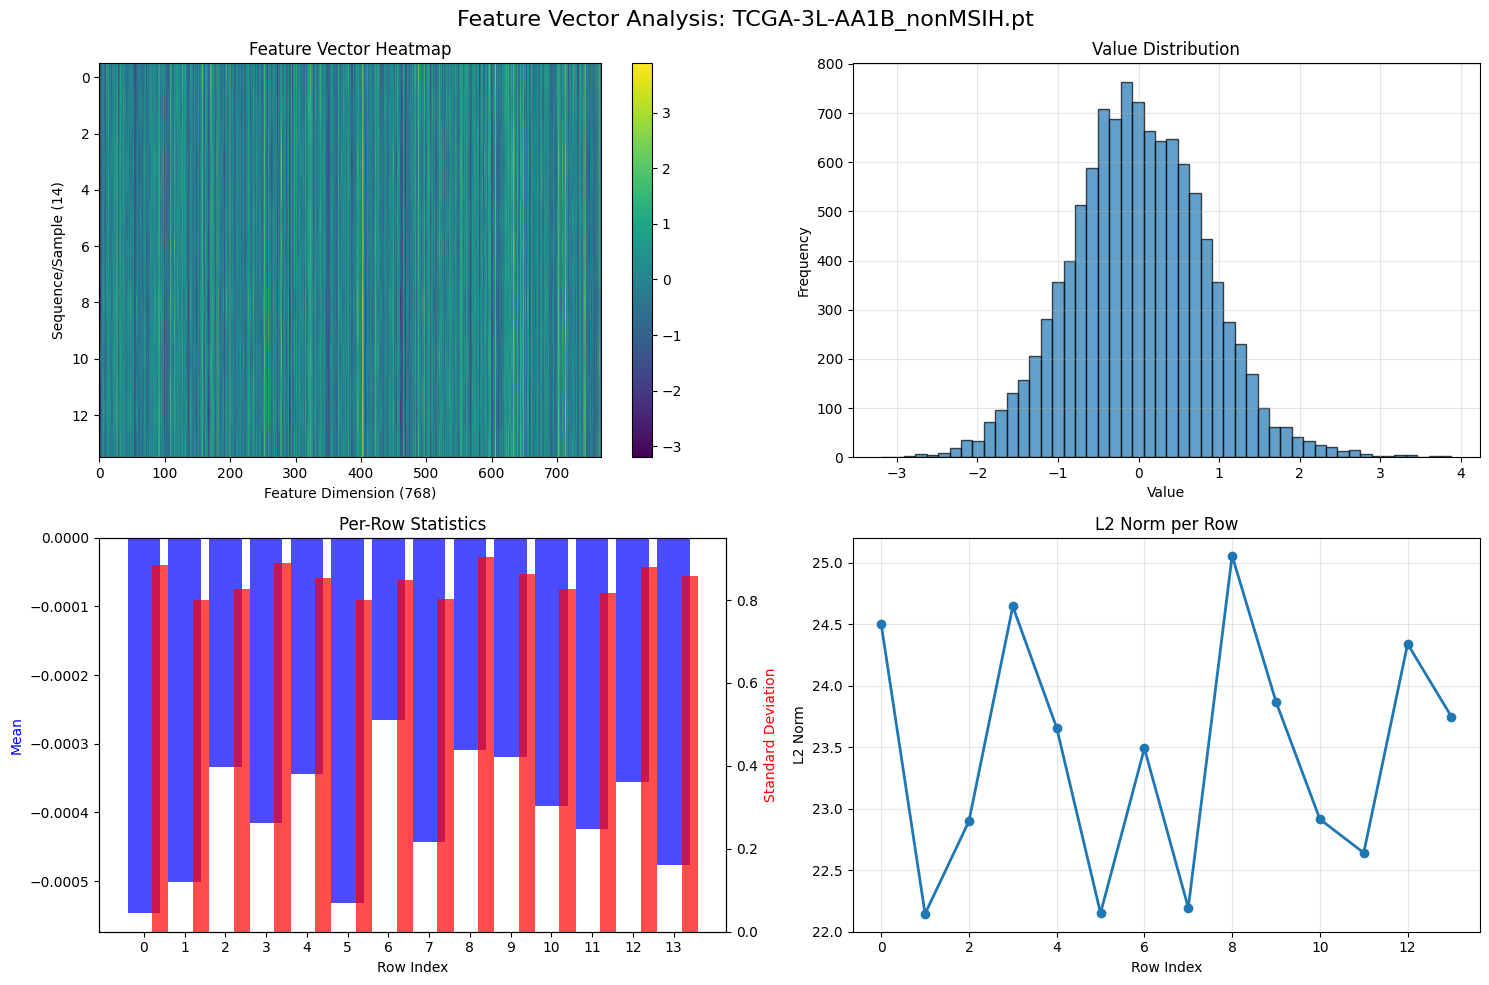

   Visualizations saved to: D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Other_Aggregations\caption_generation\Test_aggregation\TCGA-3L-AA1B_nonMSIH_analysis.png


In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def analyze_pt_file(file_path):
    """
    Comprehensive analysis of a .pt file containing feature vectors
    
    Args:
        file_path (str): Path to the .pt file
    """
    
    print("=" * 60)
    print("PYTORCH FEATURE VECTOR ANALYSIS")
    print("=" * 60)
    
    try:
        # Load the tensor
        tensor = torch.load(file_path, map_location='cpu')
        print(f"✅ Successfully loaded: {file_path}")
        
    except Exception as e:
        print(f"❌ Error loading file: {e}")
        return None
    
    # Basic tensor information
    print(f"\n📊 TENSOR BASIC INFO:")
    print(f"   Type: {type(tensor)}")
    print(f"   Data type: {tensor.dtype}")
    print(f"   Device: {tensor.device}")
    print(f"   Shape: {tensor.shape}")
    print(f"   Number of dimensions: {tensor.ndim}")
    print(f"   Total elements: {tensor.numel()}")
    print(f"   Memory usage: {tensor.element_size() * tensor.numel()} bytes")
    
    # Verify expected dimensions
    expected_shape = (14, 768)
    if tensor.shape == expected_shape:
        print(f"✅ Shape matches expected {expected_shape}")
    else:
        print(f"⚠️  Shape {tensor.shape} doesn't match expected {expected_shape}")
    
    # Statistical analysis
    print(f"\n📈 STATISTICAL ANALYSIS:")
    print(f"   Min value: {tensor.min().item():.6f}")
    print(f"   Max value: {tensor.max().item():.6f}")
    print(f"   Mean: {tensor.mean().item():.6f}")
    print(f"   Std: {tensor.std().item():.6f}")
    print(f"   Median: {tensor.median().item():.6f}")
    
    # Check for special values
    nan_count = torch.isnan(tensor).sum().item()
    inf_count = torch.isinf(tensor).sum().item()
    zero_count = (tensor == 0).sum().item()
    
    print(f"\n🔍 SPECIAL VALUES CHECK:")
    print(f"   NaN values: {nan_count}")
    print(f"   Infinite values: {inf_count}")
    print(f"   Zero values: {zero_count} ({zero_count/tensor.numel()*100:.2f}%)")
    
    if nan_count > 0 or inf_count > 0:
        print("⚠️  Warning: Found NaN or infinite values!")
    
    # Per-row analysis (assuming rows are samples/sequences)
    print(f"\n📋 PER-ROW ANALYSIS:")
    for i in range(tensor.shape[0]):
        row = tensor[i]
        print(f"   Row {i:2d}: mean={row.mean().item():8.4f}, "
              f"std={row.std().item():8.4f}, "
              f"min={row.min().item():8.4f}, "
              f"max={row.max().item():8.4f}")
    
    # Value distribution analysis
    print(f"\n📊 VALUE DISTRIBUTION:")
    tensor_np = tensor.numpy()
    
    # Percentiles
    percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
    print("   Percentiles:")
    for p in percentiles:
        val = np.percentile(tensor_np, p)
        print(f"     {p:2d}th: {val:8.4f}")
    
    # Check if values look normalized
    if abs(tensor.mean().item()) < 0.1 and abs(tensor.std().item() - 1.0) < 0.1:
        print("✅ Values appear to be normalized (mean≈0, std≈1)")
    elif tensor.min().item() >= 0 and tensor.max().item() <= 1:
        print("✅ Values appear to be in [0,1] range")
    elif tensor.min().item() >= -1 and tensor.max().item() <= 1:
        print("✅ Values appear to be in [-1,1] range")
    else:
        print("ℹ️  Values don't follow common normalization patterns")
    
    # Feature vector analysis (assuming 768-dim features are common in transformers)
    if tensor.shape[1] == 768:
        print(f"\n🤖 TRANSFORMER FEATURE ANALYSIS:")
        print("   This looks like transformer embeddings (768 is common for BERT-base)")
        
        # Check feature magnitudes
        feature_norms = torch.norm(tensor, dim=1)
        print(f"   Row norms - mean: {feature_norms.mean():.4f}, std: {feature_norms.std():.4f}")
        
        # Feature correlation analysis
        correlation_matrix = torch.corrcoef(tensor)
        avg_correlation = correlation_matrix[~torch.eye(14, dtype=bool)].mean().item()
        print(f"   Average inter-row correlation: {avg_correlation:.4f}")
    
    # Generate visualizations
    create_visualizations(tensor, file_path)
    
    return tensor

def create_visualizations(tensor, file_path):
    """Create visualization plots for the tensor"""
    
    print(f"\n📊 GENERATING VISUALIZATIONS...")
    
    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Feature Vector Analysis: {Path(file_path).name}', fontsize=16)
    
    # 1. Heatmap of the tensor
    im1 = axes[0, 0].imshow(tensor.numpy(), cmap='viridis', aspect='auto')
    axes[0, 0].set_title('Feature Vector Heatmap')
    axes[0, 0].set_xlabel('Feature Dimension (768)')
    axes[0, 0].set_ylabel('Sequence/Sample (14)')
    plt.colorbar(im1, ax=axes[0, 0])
    
    # 2. Distribution of all values
    axes[0, 1].hist(tensor.numpy().flatten(), bins=50, alpha=0.7, edgecolor='black')
    axes[0, 1].set_title('Value Distribution')
    axes[0, 1].set_xlabel('Value')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Row-wise statistics
    row_means = tensor.mean(dim=1).numpy()
    row_stds = tensor.std(dim=1).numpy()
    x_pos = range(len(row_means))
    
    axes[1, 0].bar(x_pos, row_means, alpha=0.7, label='Mean', color='blue')
    ax_twin = axes[1, 0].twinx()
    ax_twin.bar([x + 0.4 for x in x_pos], row_stds, alpha=0.7, label='Std', color='red', width=0.4)
    
    axes[1, 0].set_title('Per-Row Statistics')
    axes[1, 0].set_xlabel('Row Index')
    axes[1, 0].set_ylabel('Mean', color='blue')
    ax_twin.set_ylabel('Standard Deviation', color='red')
    axes[1, 0].set_xticks(x_pos)
    
    # 4. Feature magnitude per row
    row_norms = torch.norm(tensor, dim=1).numpy()
    axes[1, 1].plot(row_norms, 'o-', linewidth=2, markersize=6)
    axes[1, 1].set_title('L2 Norm per Row')
    axes[1, 1].set_xlabel('Row Index')
    axes[1, 1].set_ylabel('L2 Norm')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save the plot
    output_path = Path(file_path).parent / f"{Path(file_path).stem}_analysis.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"   Visualizations saved to: {output_path}")

def quick_check(file_path):
    """Quick verification of tensor shape and basic properties"""
    try:
        tensor = torch.load(file_path, map_location='cpu')
        expected_shape = (14, 768)
        
        print(f"Shape: {tensor.shape} - {'✅' if tensor.shape == expected_shape else '❌'}")
        print(f"Data type: {tensor.dtype}")
        print(f"Has NaN: {'❌' if torch.isnan(tensor).any() else '✅'}")
        print(f"Has Inf: {'❌' if torch.isinf(tensor).any() else '✅'}")
        print(f"Value range: [{tensor.min().item():.4f}, {tensor.max().item():.4f}]")
        
        return tensor.shape == expected_shape and not torch.isnan(tensor).any() and not torch.isinf(tensor).any()
        
    except Exception as e:
        print(f"Error: {e}")
        return False

# Usage examples
if __name__ == "__main__":
    # Replace with your actual file path
    file_path = r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Other_Aggregations\caption_generation\Test_aggregation\TCGA-3L-AA1B_nonMSIH.pt"
    
    print("Choose analysis type:")
    print("1. Full analysis (recommended)")
    # print("2. Quick check only")
    
    # For full analysis:
    tensor = analyze_pt_file(file_path)
    
    # For quick check:
    # is_valid = quick_check(file_path)
    # print(f"File is valid: {is_valid}")
    
    # Example of how to use the tensor after verification
    """
    if tensor is not None:
        print(f"\n🎯 READY FOR USE:")
        print(f"   Tensor shape: {tensor.shape}")
        print(f"   Example: tensor[0] shape: {tensor[0].shape}")
        print(f"   Can be used in models expecting 768-dim features")
    """